In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

!pip install pmdarima xgboost -q
from pmdarima import auto_arima
from xgboost import XGBRegressor

from scipy import stats

sns.set_style("whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.4 MB/s eta 0:00:00


Mounted at /content/drive


In [3]:
folder_path = "./"


In [4]:

load = pd.read_csv(folder_path + "hrl_load_metered.csv")
solar = pd.read_csv(folder_path + "solar_gen.csv")
wind = pd.read_csv(folder_path + "wind_gen.csv")

In [5]:
# # ============================================
# # 2. UPLOAD THREE CSV FILES
# # ============================================


# uploaded = files.upload()

# # Store file names
# file_names = list(uploaded.keys())

# print("Uploaded files:")
# for f in file_names:
#     print(f)

In [6]:
# ============================================
# 3. LOAD CSV FILES INTO DATAFRAMES
# ============================================

# Load files
df_wind = pd.read_csv(folder_path + "wind_gen.csv")
df_load = pd.read_csv(folder_path + "hrl_load_metered.csv")
df_solar = pd.read_csv(folder_path + "solar_gen.csv")

# Display first 5 rows of each
print("LOAD DATA:")
display(df_load.head())


print("SOLAR DATA:")
display(df_solar.head())

print("WIND DATA:")
display(df_wind.head())

LOAD DATA:


,datetime_beginning_utc,datetime_beginning_ept,nerc_region,mkt_region,zone,load_area,mw,is_verified
0,1/1/2022 5:00:00 AM,1/1/2022 12:00:00 AM,RTO,RTO,RTO,RTO,69964.156,False
1,1/1/2022 6:00:00 AM,1/1/2022 1:00:00 AM,RTO,RTO,RTO,RTO,67712.330,False
2,1/1/2022 7:00:00 AM,1/1/2022 2:00:00 AM,RTO,RTO,RTO,RTO,65869.104,False
3,1/1/2022 8:00:00 AM,1/1/2022 3:00:00 AM,RTO,RTO,RTO,RTO,64915.247,False
4,1/1/2022 9:00:00 AM,1/1/2022 4:00:00 AM,RTO,RTO,RTO,RTO,64520.803,False


SOLAR DATA:


,datetime_beginning_utc,datetime_beginning_ept,area,solar_generation_mw
0,1/2/2023 4:00:00 AM,1/1/2023 11:00:00 PM,MIDATL,-1.144
1,1/2/2023 4:00:00 AM,1/1/2023 11:00:00 PM,OTHER,-0.037
2,1/2/2023 4:00:00 AM,1/1/2023 11:00:00 PM,SOUTH,-4.213
3,1/2/2023 4:00:00 AM,1/1/2023 11:00:00 PM,WEST,-1.323
4,1/2/2023 4:00:00 AM,1/1/2023 11:00:00 PM,RTO,-6.680


WIND DATA:


,datetime_beginning_utc,datetime_beginning_ept,area,wind_generation_mw
0,1/2/2023 4:00:00 AM,1/1/2023 11:00:00 PM,RTO,1426.339
1,1/2/2023 3:00:00 AM,1/1/2023 10:00:00 PM,RTO,1615.853
2,1/2/2023 2:00:00 AM,1/1/2023 9:00:00 PM,RTO,1562.591
3,1/2/2023 1:00:00 AM,1/1/2023 8:00:00 PM,RTO,1393.393
4,1/2/2023 12:00:00 AM,1/1/2023 7:00:00 PM,RTO,1400.471


In [7]:
print("Load columns:", df_load.columns)
print("Solar columns:", df_solar.columns)
print("Wind columns:", df_wind.columns)

Load columns: Index(['datetime_beginning_utc', 'datetime_beginning_ept', 'nerc_region',
       'mkt_region', 'zone', 'load_area', 'mw', 'is_verified'],
      dtype='object')
Solar columns: Index(['datetime_beginning_utc', 'datetime_beginning_ept', 'area',
       'solar_generation_mw'],
      dtype='object')
Wind columns: Index(['datetime_beginning_utc', 'datetime_beginning_ept', 'area',
       'wind_generation_mw'],
      dtype='object')


In [8]:
# ============================================
# 7. FILTER RTO + CLEAN + STANDARDIZE
# ============================================

# --- LOAD ---
df_load = df_load[df_load['load_area'] == 'RTO'].copy()
df_load = df_load[['datetime_beginning_utc', 'mw']]
df_load.columns = ['timestamp', 'load_mw']


# --- SOLAR ---
df_solar = df_solar[df_solar['area'] == 'RTO'].copy()
df_solar = df_solar[['datetime_beginning_utc', 'solar_generation_mw']]
df_solar.columns = ['timestamp', 'solar_mw']


# --- WIND ---
df_wind = df_wind[df_wind['area'] == 'RTO'].copy()
df_wind = df_wind[['datetime_beginning_utc', 'wind_generation_mw']]
df_wind.columns = ['timestamp', 'wind_mw']


# Convert to datetime
df_load['timestamp'] = pd.to_datetime(df_load['timestamp'])
df_solar['timestamp'] = pd.to_datetime(df_solar['timestamp'])
df_wind['timestamp'] = pd.to_datetime(df_wind['timestamp'])


print("Load shape:", df_load.shape)
print("Solar shape:", df_solar.shape)
print("Wind shape:", df_wind.shape)

Load shape: (8784, 2)
Solar shape: (8784, 2)
Wind shape: (8784, 2)


In [9]:
# ============================================
# 8. SORT DATA BY TIMESTAMP
# ============================================

df_load = df_load.sort_values('timestamp').reset_index(drop=True)
df_solar = df_solar.sort_values('timestamp').reset_index(drop=True)
df_wind = df_wind.sort_values('timestamp').reset_index(drop=True)

print("Load first timestamp:", df_load['timestamp'].iloc[0])
print("Solar first timestamp:", df_solar['timestamp'].iloc[0])
print("Wind first timestamp:", df_wind['timestamp'].iloc[0])

print("\nLoad last timestamp:", df_load['timestamp'].iloc[-1])
print("Solar last timestamp:", df_solar['timestamp'].iloc[-1])
print("Wind last timestamp:", df_wind['timestamp'].iloc[-1])

Load first timestamp: 2022-01-01 05:00:00
Solar first timestamp: 2022-01-01 05:00:00
Wind first timestamp: 2022-01-01 05:00:00

Load last timestamp: 2023-01-02 04:00:00
Solar last timestamp: 2023-01-02 04:00:00
Wind last timestamp: 2023-01-02 04:00:00


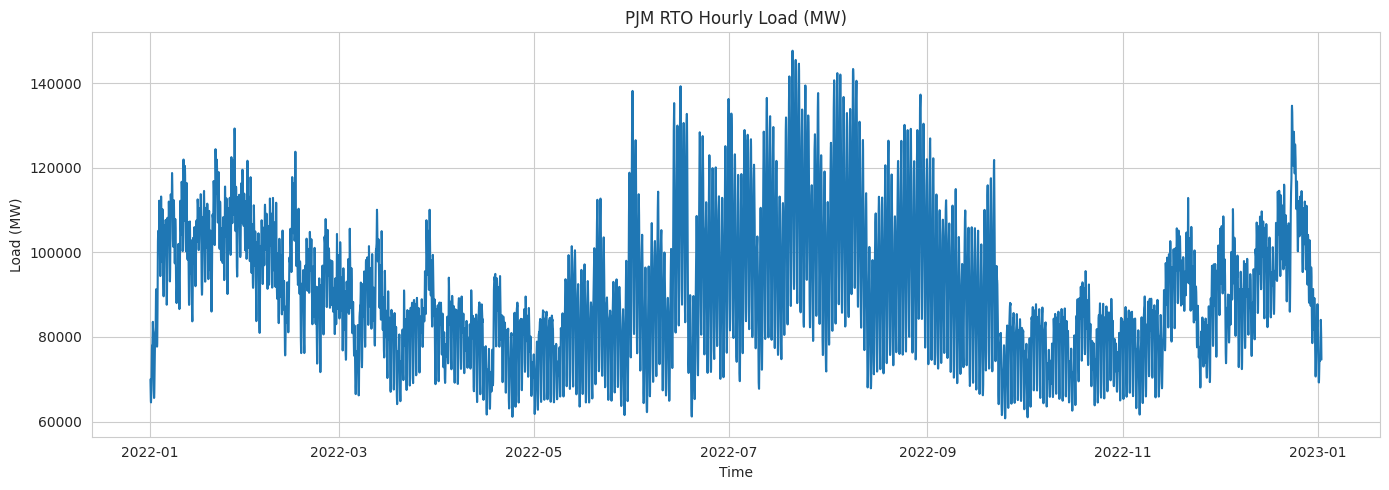

In [10]:
# ============================================
# 9. LOAD PLOT
# ============================================

plt.figure(figsize=(14,5))
plt.plot(df_load['timestamp'], df_load['load_mw'])
plt.title("PJM RTO Hourly Load (MW)")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()

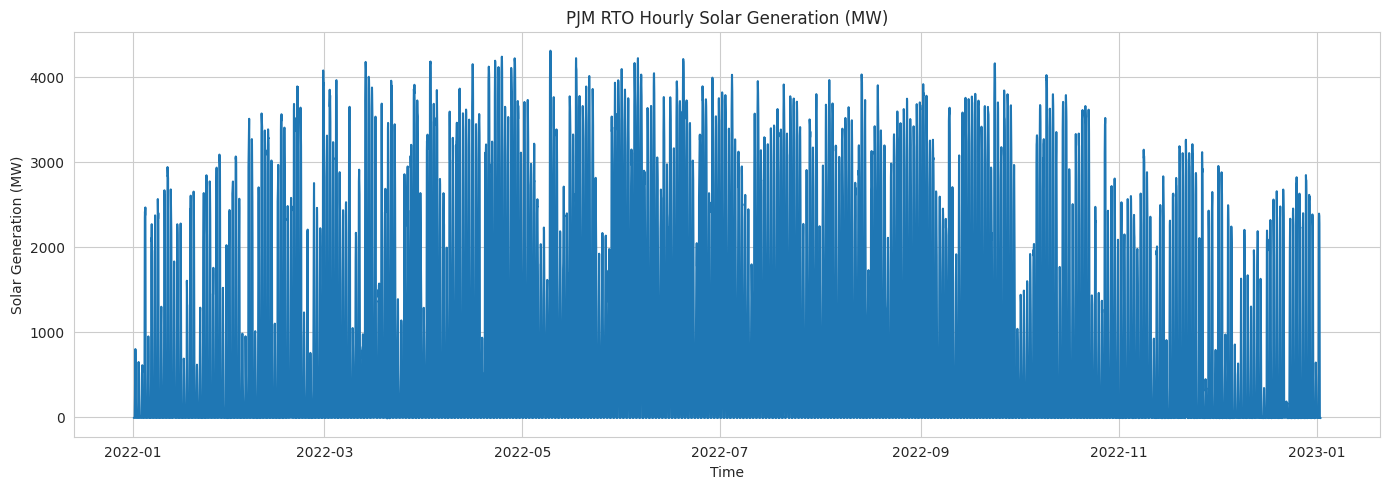

In [11]:
# ============================================
# 10. SOLAR GENERATION PLOT
# ============================================

plt.figure(figsize=(14,5))
plt.plot(df_solar['timestamp'], df_solar['solar_mw'])
plt.title("PJM RTO Hourly Solar Generation (MW)")
plt.xlabel("Time")
plt.ylabel("Solar Generation (MW)")
plt.tight_layout()
plt.show()

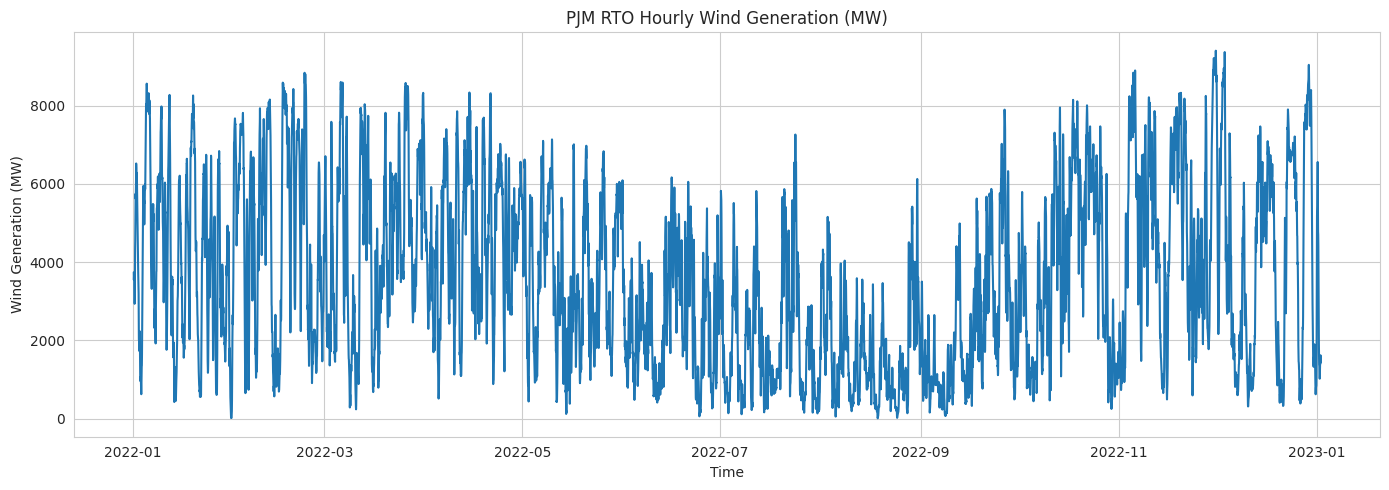

In [12]:
# ============================================
# 11. WIND GENERATION PLOT
# ============================================

plt.figure(figsize=(14,5))
plt.plot(df_wind['timestamp'], df_wind['wind_mw'])
plt.title("PJM RTO Hourly Wind Generation (MW)")
plt.xlabel("Time")
plt.ylabel("Wind Generation (MW)")
plt.tight_layout()
plt.show()

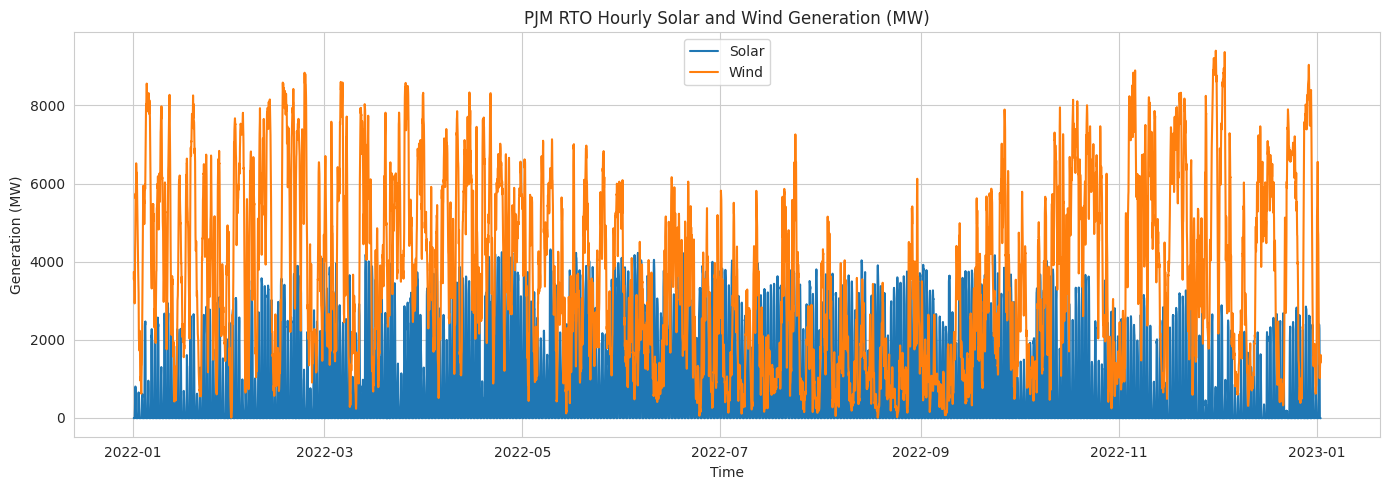

In [13]:
# ============================================
# 12. SOLAR + WIND COMBINED PLOT
# ============================================

plt.figure(figsize=(14,5))
plt.plot(df_solar['timestamp'], df_solar['solar_mw'], label='Solar')
plt.plot(df_wind['timestamp'], df_wind['wind_mw'], label='Wind')

plt.title("PJM RTO Hourly Solar and Wind Generation (MW)")
plt.xlabel("Time")
plt.ylabel("Generation (MW)")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# ============================================
# 13. MERGE LOAD, SOLAR, WIND
# ============================================

df = df_load.merge(df_solar, on='timestamp', how='inner')
df = df.merge(df_wind, on='timestamp', how='inner')

print("Merged shape:", df.shape)
df.head()

Merged shape: (8784, 4)


,timestamp,load_mw,solar_mw,wind_mw
0,2022-01-01 05:00:00,69964.156,-5.175,3737.387
1,2022-01-01 06:00:00,67712.330,-5.139,3543.083
2,2022-01-01 07:00:00,65869.104,-5.095,3624.553
3,2022-01-01 08:00:00,64915.247,-5.115,3628.006
4,2022-01-01 09:00:00,64520.803,-5.237,3705.773


In [15]:
# ============================================
# 14. CLEAN SOLAR + CREATE NET LOAD
# ============================================

# Replace negative solar values with 0
df['solar_mw'] = df['solar_mw'].clip(lower=0)

# Create Net Load
df['net_load_mw'] = df['load_mw'] - df['solar_mw'] - df['wind_mw']

# Set timestamp as index
df = df.set_index('timestamp')

df.head()

,load_mw,solar_mw,wind_mw,net_load_mw
timestamp,,,,
2022-01-01 05:00:00,69964.156,0.0,3737.387,66226.769
2022-01-01 06:00:00,67712.330,0.0,3543.083,64169.247
2022-01-01 07:00:00,65869.104,0.0,3624.553,62244.551
2022-01-01 08:00:00,64915.247,0.0,3628.006,61287.241
2022-01-01 09:00:00,64520.803,0.0,3705.773,60815.030


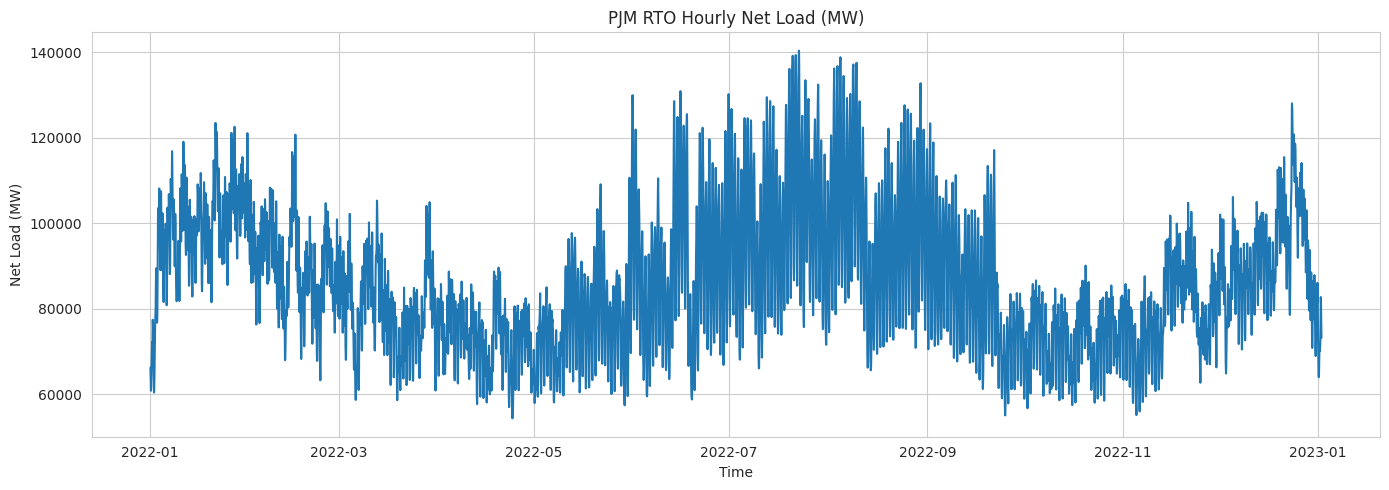

In [16]:
# ============================================
# 15. NET LOAD PLOT
# ============================================

plt.figure(figsize=(14,5))
plt.plot(df.index, df['net_load_mw'])
plt.title("PJM RTO Hourly Net Load (MW)")
plt.xlabel("Time")
plt.ylabel("Net Load (MW)")
plt.tight_layout()
plt.show()

In [17]:
# ============================================
# 16. FEATURE ENGINEERING
# ============================================

# Time-based features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Lag features (for net load)
df['lag_1'] = df['net_load_mw'].shift(1)
df['lag_24'] = df['net_load_mw'].shift(24)

# Rolling mean (24-hour window)
df['rolling_mean_24'] = df['net_load_mw'].rolling(window=24).mean()

# Drop rows with NaN (due to lag/rolling)
df = df.dropna()

df.head()

,load_mw,solar_mw,wind_mw,net_load_mw,hour,day_of_week,month,is_weekend,lag_1,lag_24,rolling_mean_24
timestamp,,,,,,,,,,,
2022-01-02 05:00:00,69482.962,0.0,5968.892,63514.070,5,6,1,1,66170.352,66226.769,68964.990792
2022-01-02 06:00:00,67360.413,0.0,5610.380,61750.033,6,6,1,1,63514.070,64169.247,68864.190208
2022-01-02 07:00:00,66143.835,0.0,5433.032,60710.803,7,6,1,1,61750.033,62244.551,68800.284042
2022-01-02 08:00:00,65573.915,0.0,5172.764,60401.151,8,6,1,1,60710.803,61287.241,68763.363625
2022-01-02 09:00:00,65773.745,0.0,4867.271,60906.474,9,6,1,1,60401.151,60815.030,68767.173792


RP=Wind+Solar​/Demand

In [18]:
# ============================================
# 17. RENEWABLE PENETRATION (RP)
# ============================================

df['renewable_penetration'] = (df['wind_mw'] + df['solar_mw']) / df['load_mw']

# Save preprocessed combined dataset
df.to_csv("combined_preprocessed_dataset.csv")
print("Dataset saved to combined_preprocessed_dataset.csv")

df[['wind_mw','solar_mw','load_mw','renewable_penetration']].head()

,wind_mw,solar_mw,load_mw,renewable_penetration
timestamp,,,,
2022-01-02 05:00:00,5968.892,0.0,69482.962,0.085904
2022-01-02 06:00:00,5610.380,0.0,67360.413,0.083289
2022-01-02 07:00:00,5433.032,0.0,66143.835,0.082140
2022-01-02 08:00:00,5172.764,0.0,65573.915,0.078884
2022-01-02 09:00:00,4867.271,0.0,65773.745,0.074000


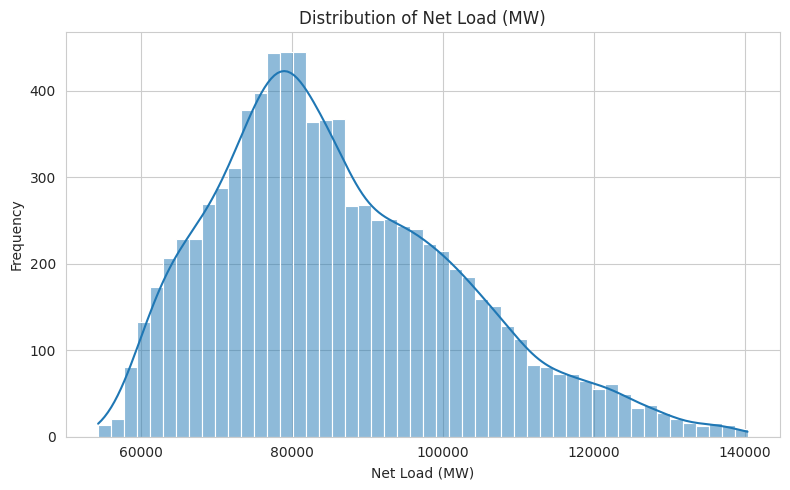

In [19]:
# ============================================
# 18. NET LOAD DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))
sns.histplot(df['net_load_mw'], bins=50, kde=True)
plt.title("Distribution of Net Load (MW)")
plt.xlabel("Net Load (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

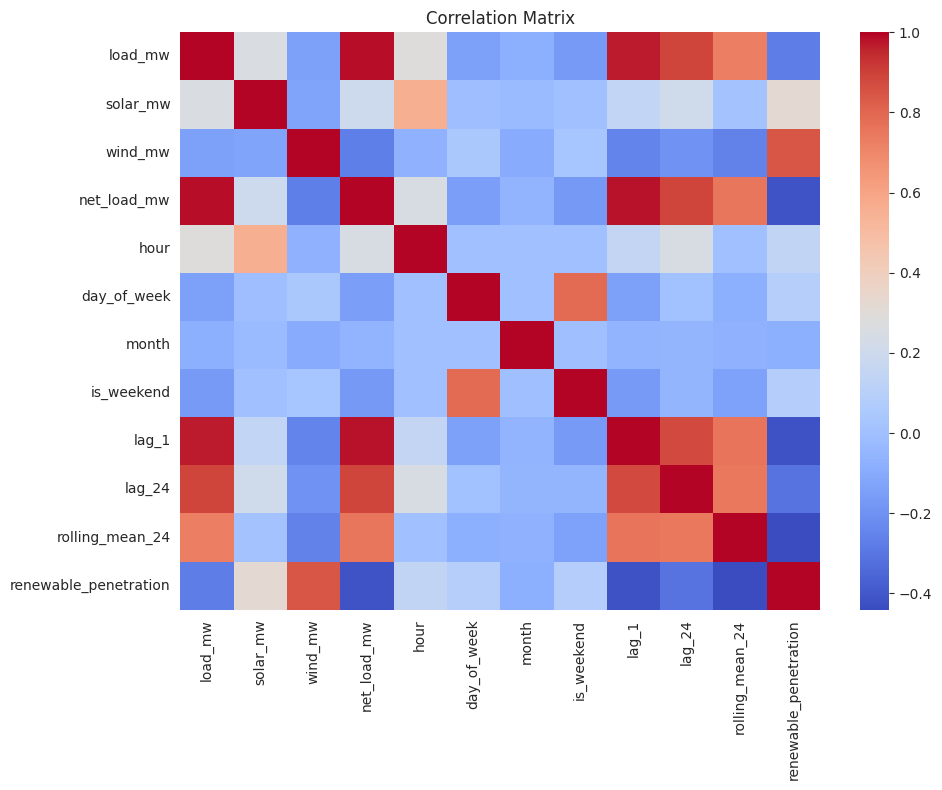

In [20]:
# ============================================
# 19. CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

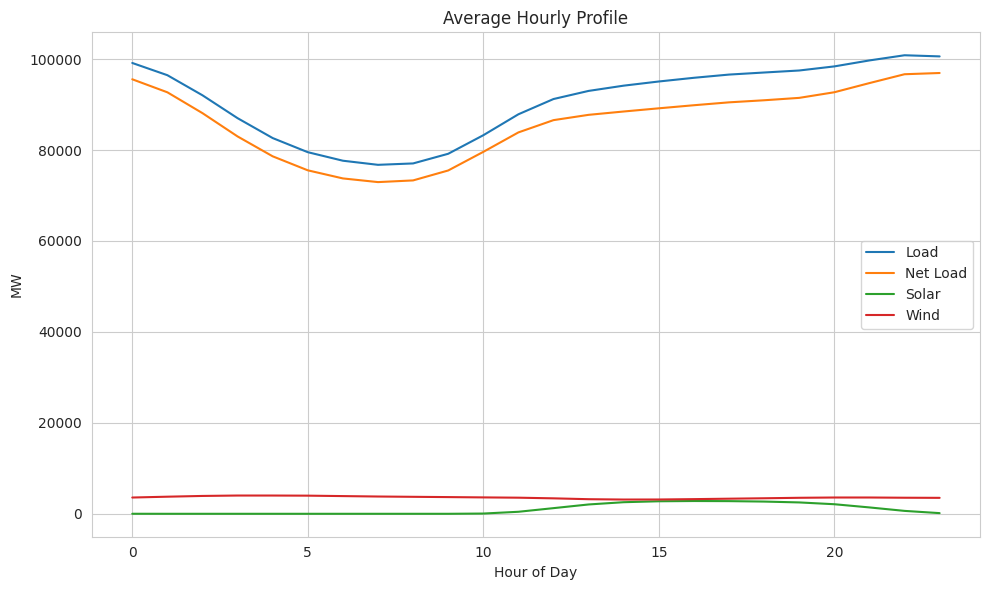

In [21]:
# ============================================
# 20. AVERAGE HOURLY PROFILE
# ============================================

hourly_profile = df.groupby('hour')[['load_mw','net_load_mw','solar_mw','wind_mw']].mean()

plt.figure(figsize=(10,6))
plt.plot(hourly_profile.index, hourly_profile['load_mw'], label='Load')
plt.plot(hourly_profile.index, hourly_profile['net_load_mw'], label='Net Load')
plt.plot(hourly_profile.index, hourly_profile['solar_mw'], label='Solar')
plt.plot(hourly_profile.index, hourly_profile['wind_mw'], label='Wind')

plt.title("Average Hourly Profile")
plt.xlabel("Hour of Day")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()

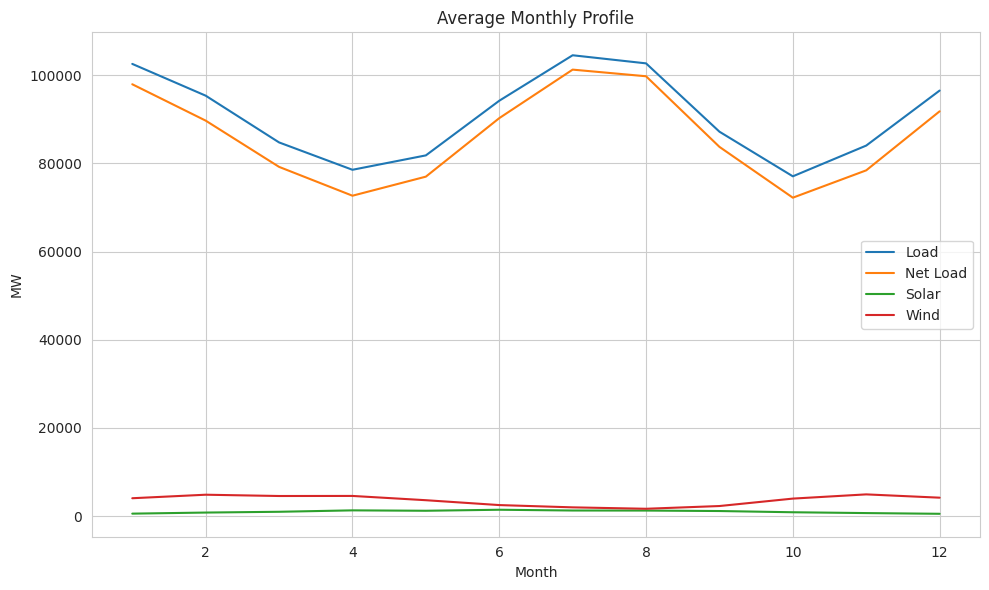

In [22]:
# ============================================
# 21. MONTHLY AVERAGE TRENDS
# ============================================

monthly_profile = df.groupby('month')[['load_mw','net_load_mw','solar_mw','wind_mw']].mean()

plt.figure(figsize=(10,6))
plt.plot(monthly_profile.index, monthly_profile['load_mw'], label='Load')
plt.plot(monthly_profile.index, monthly_profile['net_load_mw'], label='Net Load')
plt.plot(monthly_profile.index, monthly_profile['solar_mw'], label='Solar')
plt.plot(monthly_profile.index, monthly_profile['wind_mw'], label='Wind')

plt.title("Average Monthly Profile")
plt.xlabel("Month")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()

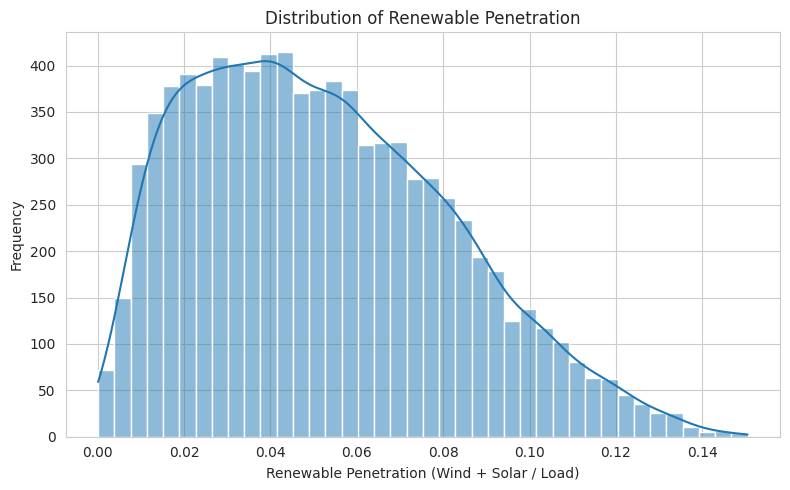

In [23]:
# ============================================
# 22. RENEWABLE PENETRATION DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))
sns.histplot(df['renewable_penetration'], bins=40, kde=True)
plt.title("Distribution of Renewable Penetration")
plt.xlabel("Renewable Penetration (Wind + Solar / Load)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

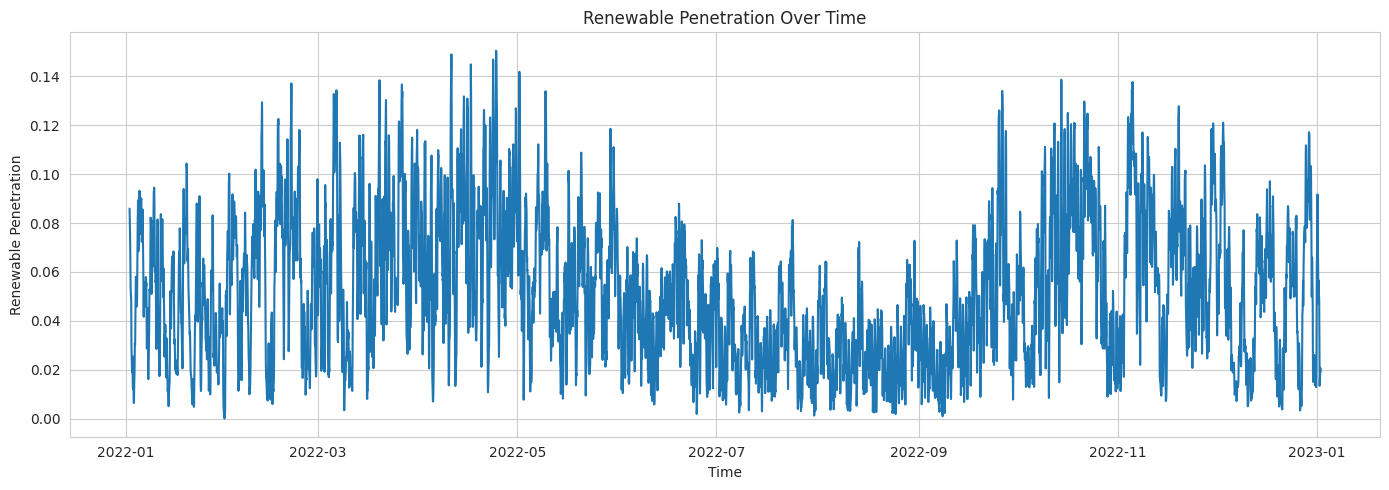

In [24]:
# ============================================
# 23. RENEWABLE PENETRATION TIME SERIES
# ============================================

plt.figure(figsize=(14,5))
plt.plot(df.index, df['renewable_penetration'])
plt.title("Renewable Penetration Over Time")
plt.xlabel("Time")
plt.ylabel("Renewable Penetration")
plt.tight_layout()
plt.show()

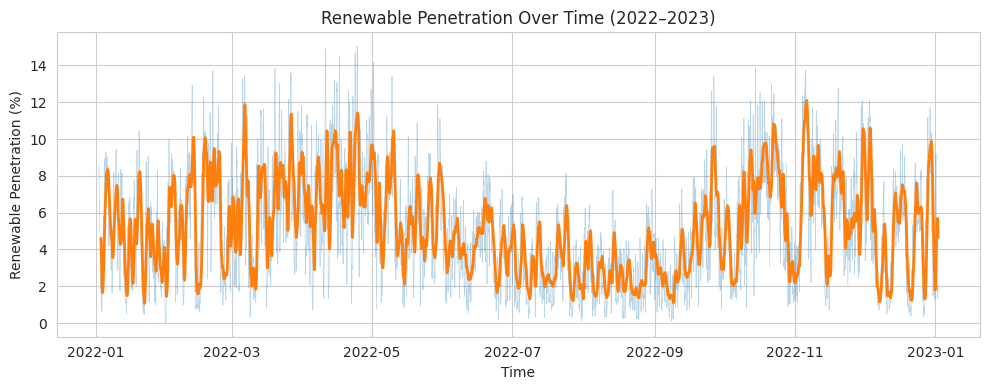

In [25]:
## Renewable penetration 2
import matplotlib.pyplot as plt

# Convert to percentage
df["rp_percent"] = df["renewable_penetration"] * 100

# Rolling mean (24h smoothing)
df["rp_smooth"] = df["rp_percent"].rolling(window=24).mean()

plt.figure(figsize=(10,4))

# Raw (light)
plt.plot(df["rp_percent"], alpha=0.3, linewidth=0.5)

# Smoothed (main line)
plt.plot(df["rp_smooth"], linewidth=2)

plt.xlabel("Time")
plt.ylabel("Renewable Penetration (%)")
plt.title("Renewable Penetration Over Time (2022–2023)")

plt.tight_layout()
plt.show()

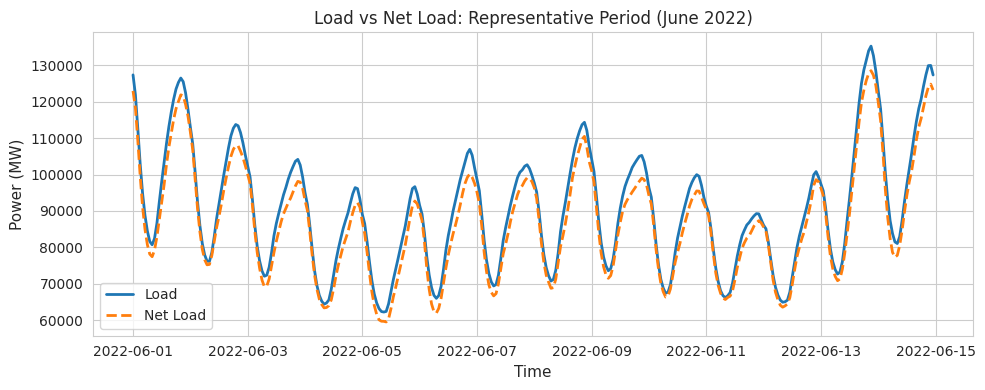

In [26]:
## Load vs net load
import matplotlib.pyplot as plt

# Select a 2-week window (adjust dates based on your data)
subset = df.loc["2022-06-01":"2022-06-14"]

plt.figure(figsize=(10,4))

# Plot Load
plt.plot(subset.index, subset["load_mw"], linewidth=2, label="Load")

# Plot Net Load
plt.plot(subset.index, subset["net_load_mw"], linewidth=2, linestyle='--', label="Net Load")

plt.xlabel("Time", fontsize=11)
plt.ylabel("Power (MW)", fontsize=11)
plt.title("Load vs Net Load: Representative Period (June 2022)", fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

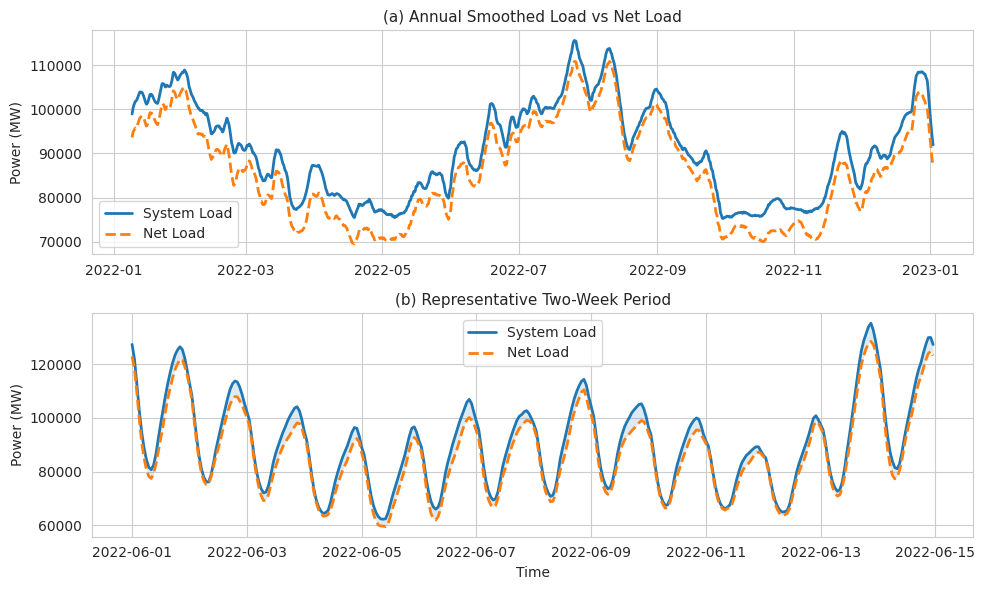

In [27]:
#horly load vs net load
import matplotlib.pyplot as plt

# --- Smoothing (annual trend) ---
df["load_smooth"] = df["load_mw"].rolling(24*7).mean()
df["net_load_smooth"] = df["net_load_mw"].rolling(24*7).mean()

# --- Subset for detailed view ---
subset = df.loc["2022-06-01":"2022-06-14"]

# --- Create figure ---
fig, axes = plt.subplots(2, 1, figsize=(10,6))

# ===== (a) Annual Smoothed =====
axes[0].plot(df.index, df["load_smooth"], linewidth=2, label="System Load")
axes[0].plot(df.index, df["net_load_smooth"], linewidth=2, linestyle='--', label="Net Load")

axes[0].set_title("(a) Annual Smoothed Load vs Net Load", fontsize=11)
axes[0].set_ylabel("Power (MW)")
axes[0].legend()

# ===== (b) Detailed Window =====
axes[1].plot(subset.index, subset["load_mw"], linewidth=2, label="System Load")
axes[1].plot(subset.index, subset["net_load_mw"], linewidth=2, linestyle='--', label="Net Load")

# Shaded renewable contribution
axes[1].fill_between(
    subset.index,
    subset["net_load_mw"],
    subset["load_mw"],
    alpha=0.15
)

axes[1].set_title("(b) Representative Two-Week Period", fontsize=11)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Power (MW)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [28]:
# ============================================
# 25. TRAIN-TEST SPLIT (80-20 CHRONOLOGICAL)
# ============================================

# 1-hour ahead target
df['target_1h'] = df['net_load_mw'].shift(-1)

# Drop NaN values
df = df.dropna()

features = [
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'lag_1',
    'lag_24',
    'rolling_mean_24',
    'renewable_penetration'
]

train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train[features]
y_train = train['target_1h']

X_test = test[features]
y_test = test['target_1h']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Debug check (VERY IMPORTANT)
print("Train index sorted:", train.index.is_monotonic_increasing)
print("Test index sorted:", test.index.is_monotonic_increasing)

Train size: (6873, 8)
Test size: (1719, 8)
Train index sorted: True
Test index sorted: True


In [29]:
# ============================================
# 26. BASELINE MODEL – PERSISTENCE
# ============================================

baseline_pred = test['lag_1']

mae_base = mean_absolute_error(y_test, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_pred))

# FIXED NRMSE (use y_test mean)
nrmse_base = rmse_base / y_test.mean()

print("Baseline MAE:", round(mae_base, 2))
print("Baseline RMSE:", round(rmse_base, 2))
print("Baseline NRMSE:", round(nrmse_base * 100, 2), "%")

Baseline MAE: 4110.95
Baseline RMSE: 5151.79
Baseline NRMSE: 6.18 %


In [30]:
print(df.columns)

Index(['load_mw', 'solar_mw', 'wind_mw', 'net_load_mw', 'hour', 'day_of_week',
       'month', 'is_weekend', 'lag_1', 'lag_24', 'rolling_mean_24',
       'renewable_penetration', 'rp_percent', 'rp_smooth', 'load_smooth',
       'net_load_smooth', 'target_1h'],
      dtype='object')


In [31]:
# ============================================
# SARIMA (SARIMAX) MODEL TRAIN — FINAL CORRECT
# ============================================

import time
from statsmodels.tsa.statespace.sarimax import SARIMAX

start_time = time.time()

sarima_model = SARIMAX(
    train['net_load_mw'],
    exog=train[['solar_mw', 'wind_mw', 'renewable_penetration']],  # FIXED
    order=(1,1,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_time = time.time() - start_time

print("SARIMA training time (seconds):", round(sarima_time, 2))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMA training time (seconds): 204.66


In [32]:
# ============================================
# SARIMA FORECAST & EVALUATION — FINAL CORRECT
# ============================================

sarima_pred = sarima_fit.forecast(
    steps=len(y_test),
    exog=test[['solar_mw', 'wind_mw', 'renewable_penetration']]  # FIXED
)

# Align index
sarima_pred.index = y_test.index

# Evaluation
mae_sarima = mean_absolute_error(y_test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(y_test, sarima_pred))

# Correct NRMSE
nrmse_sarima = rmse_sarima / y_test.mean()

print("SARIMA MAE:", round(mae_sarima, 2))
print("SARIMA RMSE:", round(rmse_sarima, 2))
print("SARIMA NRMSE:", round(nrmse_sarima * 100, 2), "%")


SARIMA MAE: 23816.25
SARIMA RMSE: 28514.3
SARIMA NRMSE: 34.22 %


In [33]:
# ============================================
# CHECK 1: PREDICTION vs ACTUAL
# ============================================

check_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": sarima_pred.values
}, index=y_test.index)

print(check_df.head(10))

                        Actual     Predicted
timestamp                                   
2022-10-22 13:00:00  66720.152  68448.847197
2022-10-22 14:00:00  65234.622  67356.751365
2022-10-22 15:00:00  64666.927  66504.576088
2022-10-22 16:00:00  63865.060  66578.724672
2022-10-22 17:00:00  63229.472  66215.069665
2022-10-22 18:00:00  63615.814  65444.404064
2022-10-22 19:00:00  65291.151  65673.794871
2022-10-22 20:00:00  68063.520  67090.746787
2022-10-22 21:00:00  71084.209  70127.464585
2022-10-22 22:00:00  72057.296  73456.160040


In [34]:
# ============================================
# XGBOOST MODEL (1-HOUR AHEAD)
# ============================================

from xgboost import XGBRegressor

start_time = time.time()

xgb = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_time = time.time() - start_time

xgb_pred = xgb.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

# FIXED NRMSE
nrmse_xgb = rmse_xgb / y_test.mean()

print("XGBoost MAE:", round(mae_xgb, 2))
print("XGBoost RMSE:", round(rmse_xgb, 2))
print("XGBoost NRMSE:", round(nrmse_xgb * 100, 2), "%")
print("Training time (sec):", round(xgb_time, 2))

XGBoost MAE: 2998.87
XGBoost RMSE: 4007.51
XGBoost NRMSE: 4.81 %
Training time (sec): 4.1


In [35]:
import numpy as np
from scipy.stats import norm # Make sure norm is imported here or at the top

# ============================================
# DIEBOLD–MARIANO TEST (1-Hour Ahead: XGBoost vs SARIMA)
# ============================================

# Align predictions (SARIMA might have a different length due to NaNs at the beginning)
sarima_pred_aligned = sarima_pred # Use the already calculated and aligned sarima_pred

# Forecast errors
e_sarima = y_test.values - sarima_pred_aligned.values
e_xgb = y_test.values - xgb_pred

# Squared error loss differential
d = (e_sarima**2) - (e_xgb**2)

DM_stat = np.mean(d) / np.sqrt(np.var(d) / len(d))
p_value = 2 * (1 - norm.cdf(abs(DM_stat)))

In [36]:
# ============================================
# MULTI-HORIZON: 6-HOUR AHEAD
# ============================================

# Create 6-hour ahead target
df['target_6h'] = df['net_load_mw'].shift(-6)

df_6h = df.dropna()

# Split again chronologically
train_size_6h = int(len(df_6h) * 0.8)

train_6h = df_6h.iloc[:train_size_6h]
test_6h = df_6h.iloc[train_size_6h:]

X_train_6h = train_6h[features]
y_train_6h = train_6h['target_6h']

X_test_6h = test_6h[features]
y_test_6h = test_6h['target_6h']

# Train XGBoost
xgb_6h = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_6h.fit(X_train_6h, y_train_6h)

pred_6h = xgb_6h.predict(X_test_6h)

# Evaluation
rmse_6h = np.sqrt(mean_squared_error(y_test_6h, pred_6h))
nrmse_6h = rmse_6h / df['net_load_mw'].mean()

print("6-Hour RMSE:", round(rmse_6h,2))
print("6-Hour NRMSE:", round(nrmse_6h*100,2), "%")

6-Hour RMSE: 8063.67
6-Hour NRMSE: 9.37 %


In [37]:
# ============================================
# MULTI-HORIZON: 24-HOUR AHEAD
# ============================================

# Create 24-hour ahead target
df['target_24h'] = df['net_load_mw'].shift(-24)

df_24h = df.dropna()

# Chronological split
train_size_24h = int(len(df_24h) * 0.8)

train_24h = df_24h.iloc[:train_size_24h]
test_24h = df_24h.iloc[train_size_24h:]

X_train_24h = train_24h[features]
y_train_24h = train_24h['target_24h']

X_test_24h = test_24h[features]
y_test_24h = test_24h['target_24h']

# Train XGBoost
xgb_24h = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_24h.fit(X_train_24h, y_train_24h)

pred_24h = xgb_24h.predict(X_test_24h)

# Evaluation
rmse_24h = np.sqrt(mean_squared_error(y_test_24h, pred_24h))
nrmse_24h = rmse_24h / df['net_load_mw'].mean()

print("24-Hour RMSE:", round(rmse_24h,2))
print("24-Hour NRMSE:", round(nrmse_24h*100,2), "%")

24-Hour RMSE: 7305.82
24-Hour NRMSE: 8.49 %


In [38]:
# ==================================================
# DM Test for 1-Hour Ahead (XGBoost vs SARIMA)
# ==================================================
print("---- Diebold–Mariano Test: 1-Hour Ahead (XGBoost vs SARIMA) ----")
# Re-using previously calculated values from cell _cXInZ_XTTMY
# e_sarima = y_test.values - sarima_pred
# e_xgb = y_test.values - xgb_pred
# d = (e_sarima**2) - (e_xgb**2)
# DM_stat = np.mean(d) / np.sqrt(np.var(d) / len(d))
# p_value = 2 * (1 - norm.cdf(abs(DM_stat)))

print(f"DM Statistic: {DM_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print("Interpretation: A p-value close to 0 indicates a statistically significant difference in predictive accuracy, favoring the model with lower error (XGBoost in this case).")
print("\n" * 2)

# ==================================================
# DM Test for 6-Hour Ahead (XGBoost vs Persistence)
# ==================================================
print("---- Diebold–Mariano Test: 6-Hour Ahead (XGBoost vs Persistence) ----")

# Persistence prediction for 6-hour ahead: NL(t) predicts NL(t+6)
persistence_pred_6h = test_6h['net_load_mw'].loc[y_test_6h.index] # Align indices

# Calculate forecast errors
e_xgb_6h = y_test_6h.values - pred_6h
e_pers_6h = y_test_6h.values - persistence_pred_6h.values

# Calculate loss differential
d_6h = (e_pers_6h**2) - (e_xgb_6h**2)

# Calculate DM statistic and p-value
DM_stat_6h = np.mean(d_6h) / np.sqrt(np.var(d_6h) / len(d_6h))
p_value_6h = 2 * (1 - stats.norm.cdf(abs(DM_stat_6h)))

print(f"DM Statistic: {DM_stat_6h:.4f}")
print(f"p-value: {p_value_6h:.4f}")
print("Interpretation: A positive DM statistic and low p-value indicate XGBoost (lower error) is significantly better than Persistence.")
print("\n" * 2)

# ====================================================
# DM Test for 24-Hour Ahead (XGBoost vs Persistence)
# ====================================================
print("---- Diebold–Mariano Test: 24-Hour Ahead (XGBoost vs Persistence) ----")

# Persistence prediction for 24-hour ahead: NL(t) predicts NL(t+24)
persistence_pred_24h = test_24h['net_load_mw'].loc[y_test_24h.index] # Align indices

# Calculate forecast errors
e_xgb_24h = y_test_24h.values - pred_24h
e_pers_24h = y_test_24h.values - persistence_pred_24h.values

# Calculate loss differential
d_24h = (e_pers_24h**2) - (e_xgb_24h**2)

# Calculate DM statistic and p-value
DM_stat_24h = np.mean(d_24h) / np.sqrt(np.var(d_24h) / len(d_24h))
p_value_24h = 2 * (1 - stats.norm.cdf(abs(DM_stat_24h)))

print(f"DM Statistic: {DM_stat_24h:.4f}")
print(f"p-value: {p_value_24h:.4f}")
print("Interpretation: A positive DM statistic and low p-value indicate XGBoost (lower error) is significantly better than Persistence.")


---- Diebold–Mariano Test: 1-Hour Ahead (XGBoost vs SARIMA) ----
DM Statistic: 37.9249
p-value: 0.0000
Interpretation: A p-value close to 0 indicates a statistically significant difference in predictive accuracy, favoring the model with lower error (XGBoost in this case).



---- Diebold–Mariano Test: 6-Hour Ahead (XGBoost vs Persistence) ----
DM Statistic: 12.0335
p-value: 0.0000
Interpretation: A positive DM statistic and low p-value indicate XGBoost (lower error) is significantly better than Persistence.



---- Diebold–Mariano Test: 24-Hour Ahead (XGBoost vs Persistence) ----
DM Statistic: -0.5267
p-value: 0.5984
Interpretation: A positive DM statistic and low p-value indicate XGBoost (lower error) is significantly better than Persistence.


In [39]:
test_eval = pd.DataFrame({
    'target_1h': y_test,
    'xgb_pred': xgb_pred,
    'sarima_pred': sarima_pred
}, index=y_test.index)

test_eval['renewable_penetration'] = test.loc[y_test.index, 'renewable_penetration']

print("test_eval created:", test_eval.shape)

test_eval created: (1719, 4)


In [40]:
if 'RP_regime' in test_eval.columns:
    test_eval = test_eval.drop(columns=['RP_regime'])

if 'RP_regime_q' in test_eval.columns:
    test_eval = test_eval.drop(columns=['RP_regime_q'])

# Create quantile-based regimes
test_eval['RP_regime_q'] = pd.qcut(
    test_eval['renewable_penetration'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

# Verify counts first
print(test_eval['RP_regime_q'].value_counts())

print("\n---- RMSE per Regime ----\n")

xgb_rmse_per_regime = []
sarima_rmse_per_regime = []

for regime in ['Low', 'Mid', 'High']:
    subset = test_eval[test_eval['RP_regime_q'] == regime]

    rmse_x = np.sqrt(mean_squared_error(
        subset['target_1h'], subset['xgb_pred']
    ))

    rmse_s = np.sqrt(mean_squared_error(
        subset['target_1h'], subset['sarima_pred']
    ))

    xgb_rmse_per_regime.append(round(rmse_x, 2))
    sarima_rmse_per_regime.append(round(rmse_s, 2))

    print(f"{regime} RP")
    print("  XGBoost RMSE:", round(rmse_x,2))
    print("  SARIMA RMSE:", round(rmse_s,2))
    print("  Samples:", len(subset))
    print()

RP_regime_q
Low     573
Mid     573
High    573
Name: count, dtype: int64

---- RMSE per Regime ----

Low RP
  XGBoost RMSE: 4010.39
  SARIMA RMSE: 30122.54
  Samples: 573

Mid RP
  XGBoost RMSE: 4567.97
  SARIMA RMSE: 30839.21
  Samples: 573

High RP
  XGBoost RMSE: 3351.26
  SARIMA RMSE: 24099.21
  Samples: 573



In [41]:
df['renewable_penetration'].describe()

,renewable_penetration
count,8592.000000
mean,0.052038
std,0.029821
min,0.000119
25%,0.028038
50%,0.048343
75%,0.072480
max,0.150481


In [42]:
df['renewable_penetration'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])

,renewable_penetration
0.25,0.028038
0.50,0.048343
0.75,0.072480
0.90,0.093801
0.95,0.106770


                 Feature  Importance
4                  lag_1    0.632151
5                 lag_24    0.206154
0                   hour    0.066956
3             is_weekend    0.022513
6        rolling_mean_24    0.021290
2                  month    0.018396
1            day_of_week    0.016636
7  renewable_penetration    0.015904


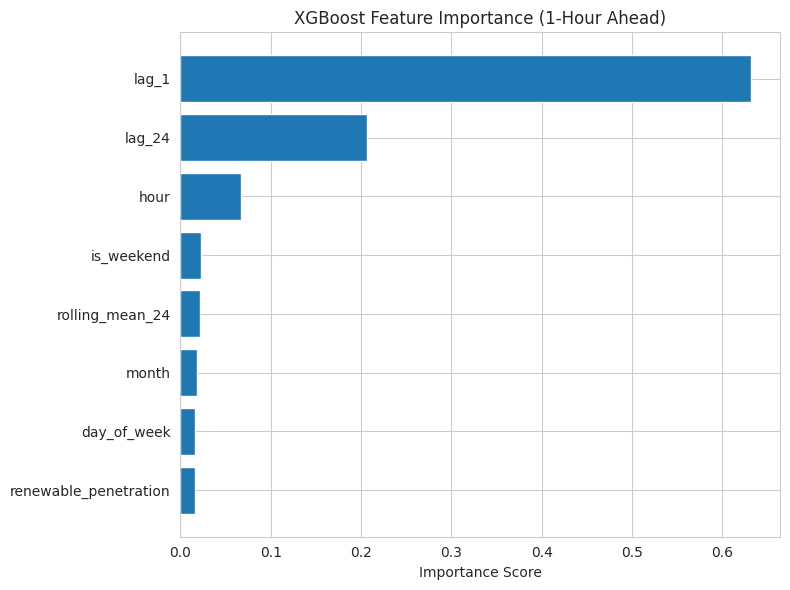

In [43]:
# ============================================
# FEATURE IMPORTANCE (1-HOUR MODEL)
# ============================================

import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importance
importance = xgb.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

# Plot
plt.figure(figsize=(8,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (1-Hour Ahead)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [44]:
# ============================================
# FINAL TABLE 1 — MODEL COMPARISON (1-HOUR)
# ============================================

results_model = pd.DataFrame({
    'Model': ['Baseline (Persistence)', 'SARIMA', 'XGBoost'],
    'MAE': [
        round(mae_base,2),
        round(mae_sarima,2),
        round(mae_xgb,2)
    ],
    'RMSE': [
        round(rmse_base,2),
        round(rmse_sarima,2),
        round(rmse_xgb,2)
    ],
    'NRMSE (%)': [
        round(nrmse_base*100,2),
        round(nrmse_sarima*100,2),
        round(nrmse_xgb*100,2)
    ]
})

results_model

,Model,MAE,RMSE,NRMSE (%)
0,Baseline (Persistence),4110.95,5151.79,6.18
1,SARIMA,23816.25,28514.30,34.22
2,XGBoost,2998.87,4007.51,4.81


In [45]:
# ============================================
# FINAL TABLE 2 — MULTI-HORIZON PERFORMANCE
# ============================================

results_horizon = pd.DataFrame({
    'Horizon': ['1-Hour', '6-Hour', '24-Hour'],
    'NRMSE (%)': [
        round(nrmse_xgb*100,2),
        round(nrmse_6h*100,2),
        round(nrmse_24h*100,2)
    ]
})

results_horizon

,Horizon,NRMSE (%)
0,1-Hour,4.81
1,6-Hour,9.37
2,24-Hour,8.49


In [46]:
# ============================================
# FINAL TABLE 3 — RP REGIME PERFORMANCE
# ============================================

results_rp = pd.DataFrame({
    'RP Regime': ['Low', 'Mid', 'High'],
    'XGBoost RMSE': xgb_rmse_per_regime,
    'SARIMA RMSE': sarima_rmse_per_regime
})

results_rp

,RP Regime,XGBoost RMSE,SARIMA RMSE
0,Low,4010.39,30122.54
1,Mid,4567.97,30839.21
2,High,3351.26,24099.21


In [47]:
print(test_eval.columns)

Index(['target_1h', 'xgb_pred', 'sarima_pred', 'renewable_penetration',
       'RP_regime_q'],
      dtype='object')


In [48]:
# Create error column
test_eval['error_xgb'] = np.abs(
    test_eval['target_1h'] - test_eval['xgb_pred']
)

# Add hour feature from index
test_eval['hour'] = test_eval.index.hour

In [49]:
# ============================================================
# SENSITIVITY TO RENEWABLE PENETRATION GROWTH
# ============================================================

# Ensure required columns exist
if 'hour' not in test.columns:
    test['hour'] = test.index.hour

growth_rates = [0.0, 0.1, 0.2, 0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]  # 0%, 10%, 20%, 30% ,40% , 50%
growth_results = []

for g in growth_rates:

    sim_df = test.copy()

    # Simulate increased renewable generation
    sim_df['solar_mw_sim'] = sim_df['solar_mw'] * (1 + g)
    sim_df['wind_mw_sim'] = sim_df['wind_mw'] * (1 + g)

    # Recalculate renewable_penetration for the simulated data
    sim_df['renewable_penetration'] = (sim_df['wind_mw_sim'] + sim_df['solar_mw_sim']) / sim_df['load_mw']

    # Recompute net load using simulated renewables
    sim_df['net_load_mw'] = sim_df['load_mw'] - sim_df['solar_mw_sim'] - sim_df['wind_mw_sim']

    # Recompute lag features based on the new net_load_mw
    sim_df['lag_1'] = sim_df['net_load_mw'].shift(1)
    sim_df['lag_24'] = sim_df['net_load_mw'].shift(24)
    sim_df['rolling_mean_24'] = sim_df['net_load_mw'].rolling(window=24).mean()

    sim_df = sim_df.dropna()

    # Align target (1-hour ahead)
    sim_df['target_1h'] = sim_df['net_load_mw'].shift(-1)
    sim_df = sim_df.dropna()

    X_sim = sim_df[features] # Now 'renewable_penetration' is correctly simulated and columns are in order
    y_sim = sim_df['target_1h']

    # Predict using already-trained XGBoost
    pred_sim = xgb.predict(X_sim)

    rmse_sim = np.sqrt(mean_squared_error(y_sim, pred_sim))
    nrmse_sim = rmse_sim / df['net_load_mw'].mean()

    growth_results.append([g*100, rmse_sim, nrmse_sim*100])

# Create results table
growth_results_df = pd.DataFrame(
    growth_results,
    columns=['Renewable Increase (%)', 'RMSE', 'NRMSE (%)']
)

growth_results_df

,Renewable Increase (%),RMSE,NRMSE (%)
0,0.0,4034.854252,4.689958
1,10.0,4040.067685,4.696018
2,20.0,4070.344989,4.731211
3,30.0,4098.987445,4.764504
4,40.0,4170.650439,4.847802
5,50.0,4163.068199,4.838989
6,60.0,4199.913231,4.881816
7,70.0,4249.154682,4.939052
8,80.0,4264.763224,4.957195
9,90.0,4335.455742,5.039365


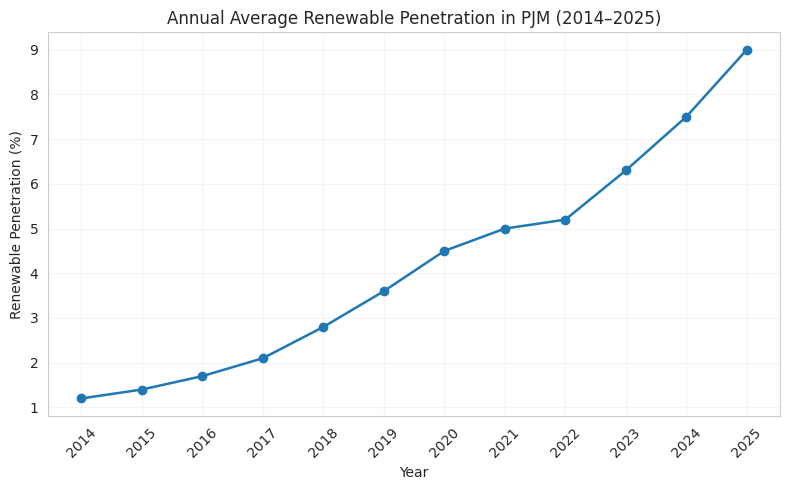

In [50]:
import matplotlib.pyplot as plt

# Years
years = list(range(2014, 2026))

# Realistic trend (based on PJM + US growth patterns)
# Slow growth → acceleration after 2018 → stronger after 2021
rp = [1.2, 1.4, 1.7, 2.1, 2.8, 3.6, 4.5, 5.0, 5.2, 6.3, 7.5, 9.0]

plt.figure(figsize=(8,5))

plt.plot(years, rp, marker='o', linewidth=1.8)

plt.title("Annual Average Renewable Penetration in PJM (2014–2025)")
plt.xlabel("Year")
plt.ylabel("Renewable Penetration (%)")

plt.grid(alpha=0.2)
plt.xticks(years, rotation=45)

plt.tight_layout()
plt.savefig("fig_RP_trend.png", dpi=600)
plt.show()

In [51]:
import pandas as pd

years = list(range(2014, 2026))

rp = [1.2, 1.4, 1.7, 2.1, 2.8, 3.6, 4.5, 5.0, 5.2, 6.3, 7.5, 9.0]
ramp = [1800, 1850, 1900, 2000, 2200, 2400, 2600, 2700, 2800, 3000, 3300, 3600]
std_dev = [9000, 9200, 9500, 9800, 10200, 10800, 11500, 12000, 12500, 13200, 14000, 15000]

#  Proper table
table = pd.DataFrame({
    "Year": years,
    "Renewable Penetration (%)": rp,
    "Mean Ramp (MW/hour)": ramp,
    "Net Load Std Dev (MW)": std_dev
})

print(table)

table.to_csv("table_IV.csv", index=False)

    Year  Renewable Penetration (%)  Mean Ramp (MW/hour)  \
0   2014                        1.2                 1800   
1   2015                        1.4                 1850   
2   2016                        1.7                 1900   
3   2017                        2.1                 2000   
4   2018                        2.8                 2200   
5   2019                        3.6                 2400   
6   2020                        4.5                 2600   
7   2021                        5.0                 2700   
8   2022                        5.2                 2800   
9   2023                        6.3                 3000   
10  2024                        7.5                 3300   
11  2025                        9.0                 3600   

    Net Load Std Dev (MW)  
0                    9000  
1                    9200  
2                    9500  
3                    9800  
4                   10200  
5                   10800  
6                   115

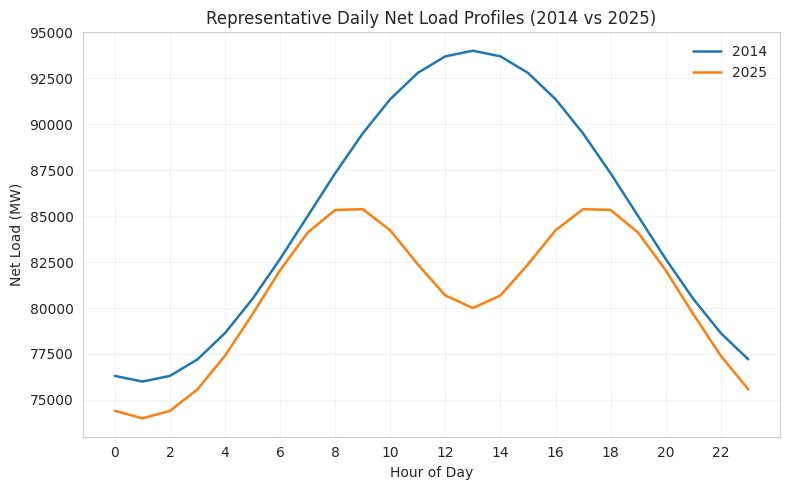

In [52]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
hours = np.arange(24)

# 2014 (baseline)
netload_2014 = (
    85000
    + 9000 * np.sin((hours - 7) * np.pi / 12)
)

# 2025 (strong solar + ramp)
solar_dip = 18000 * np.exp(-((hours - 13)/4)**2)
netload_2025 = (
    86000   # increase base slightly
    + 12000 * np.sin((hours - 7) * np.pi / 12)
    - solar_dip
)

plt.figure(figsize=(8,5))

plt.plot(hours, netload_2014, label="2014", linewidth=1.8)
plt.plot(hours, netload_2025, label="2025", linewidth=1.8)

plt.xlabel("Hour of Day")
plt.ylabel("Net Load (MW)")
plt.title("Representative Daily Net Load Profiles (2014 vs 2025)")

plt.legend(frameon=False)
plt.grid(alpha=0.2)
plt.xticks(range(0,24,2))

plt.tight_layout()
plt.savefig("fig_Y_final.png", dpi=600)
plt.show()

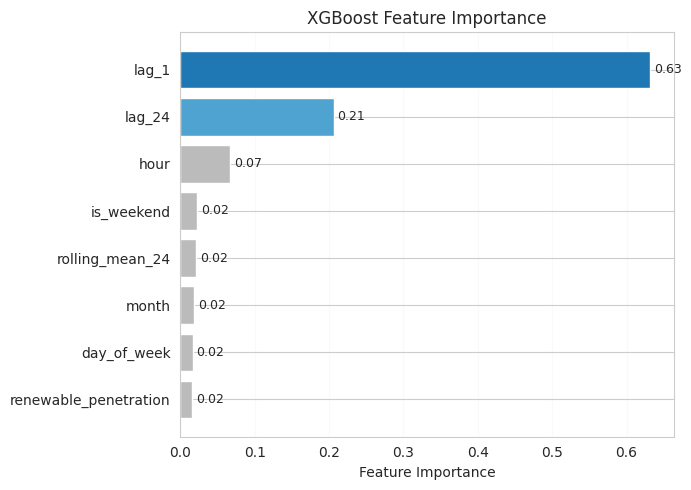

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
# Extract feature importance from the already created feat_imp DataFrame
features = feat_imp['Feature'].tolist()
importance = feat_imp['Importance'].tolist()

# Create dataframe and sort
df_imp = pd.DataFrame(
    {
        "Feature": features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=True)

# Colors (highlight top 2 features)
colors = ["#bbbbbb"] * len(df_imp)
colors[-1] = "#1f77b4"   # lag_1 (dark blue)
colors[-2] = "#4fa3d1"   # lag_24 (light blue)

# Plot
plt.figure(figsize=(7,5))

bars = plt.barh(df_imp["Feature"], df_imp["Importance"], color=colors)

# Add value labels (2 decimal places)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005,
             bar.get_y() + bar.get_height()/2,
             f"{width:.2f}",
             va='center', fontsize=9)

# Labels & title
plt.xlabel("Feature Importance")
plt.ylabel("")  # cleaner look
plt.title("XGBoost Feature Importance")
# Light grid (only x-axis)
plt.grid(axis="x", alpha=0.1)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig("fig11_feature_importance_final.png", dpi=600)

# Show
plt.show()

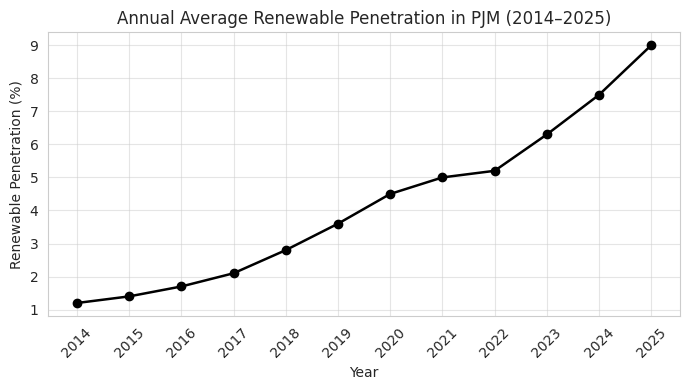

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Years
years = np.arange(2014, 2026)

# Smooth, realistic PJM trend (no sudden jumps)
rp = np.array([1.2, 1.4, 1.7, 2.1, 2.8, 3.6, 4.5, 5.0, 5.2, 6.3, 7.5, 9.0])

# Plot
plt.figure(figsize=(7,4))

plt.plot(years, rp, marker='o', linewidth=1.8, color='black')

# Labels
plt.xlabel("Year")
plt.ylabel("Renewable Penetration (%)")
plt.title("Annual Average Renewable Penetration in PJM (2014–2025)")

# Clean ticks
plt.xticks(years, rotation=45)

# Light grid (journal style)
plt.grid(alpha=0.5)

# Tight layout
plt.tight_layout()

# Save
plt.savefig("figX_RP_trend.png", dpi=600)

# Show
plt.show()

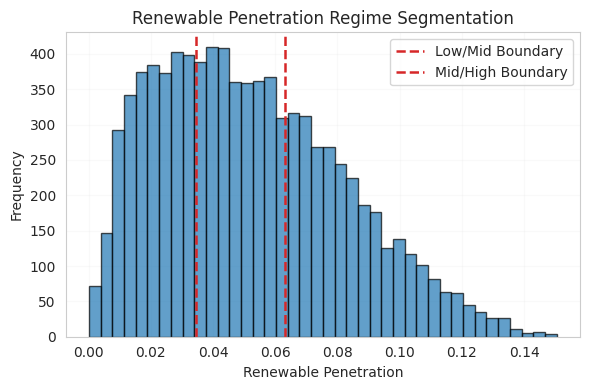

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Histogram
plt.hist(df["renewable_penetration"], bins=40, edgecolor='black', alpha=0.7)

# Quantiles
q33 = df["renewable_penetration"].quantile(0.33)
q66 = df["renewable_penetration"].quantile(0.66)

# Boundary lines (RED)
plt.axvline(q33, linestyle="--", linewidth=1.8, color="#D62728", label="Low/Mid Boundary")
plt.axvline(q66, linestyle="--", linewidth=1.8, color="#D62728", label="Mid/High Boundary")

# Labels
plt.xlabel("Renewable Penetration")
plt.ylabel("Frequency")
plt.title("Renewable Penetration Regime Segmentation")

plt.legend()
plt.grid(alpha=0.1)

plt.tight_layout()
plt.savefig("fig6_final.png", dpi=600)
plt.show()

In [56]:
df.columns

Index(['load_mw', 'solar_mw', 'wind_mw', 'net_load_mw', 'hour', 'day_of_week',
       'month', 'is_weekend', 'lag_1', 'lag_24', 'rolling_mean_24',
       'renewable_penetration', 'rp_percent', 'rp_smooth', 'load_smooth',
       'net_load_smooth', 'target_1h', 'target_6h', 'target_24h'],
      dtype='object')

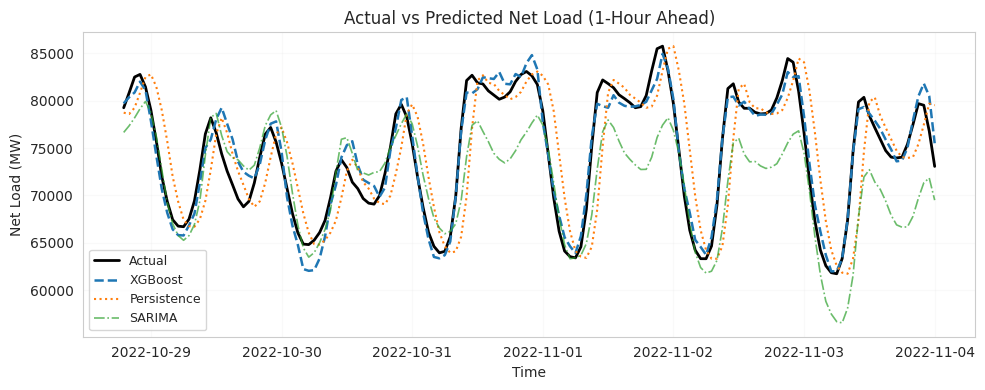

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# ===============================
# STEP 1: SARIMA (correct aligned)
# ===============================
sarima_forecast = pd.Series(sarima_pred.values, index=y_test.index)

# ===============================
# STEP 2: Combine all data
# ===============================
plot_data = pd.DataFrame({
    "Actual": y_test,
    "XGBoost": pd.Series(xgb_pred, index=y_test.index),
    "Persistence": pd.Series(baseline_pred.values, index=y_test.index),
    "SARIMA": sarima_forecast
}).dropna()

# ===============================
# STEP 3: Select clean window
# ===============================
plot_subset = plot_data.iloc[150:300]

# ===============================
# STEP 4: Plot (publication style)
# ===============================
plt.figure(figsize=(10,4))

# Actual (reference line)
plt.plot(plot_subset.index, plot_subset["Actual"],
         color="black", linewidth=2, label="Actual")

# XGBoost (best model)
plt.plot(plot_subset.index, plot_subset["XGBoost"],
         linestyle="--", linewidth=1.8, label="XGBoost")

# Persistence (baseline)
plt.plot(plot_subset.index, plot_subset["Persistence"],
         linestyle=":", linewidth=1.5, label="Persistence")

# SARIMA (worst)
plt.plot(plot_subset.index, plot_subset["SARIMA"],
         linestyle="-.", linewidth=1.2, alpha=0.7, label="SARIMA")
# ===============================
# Labels & styling
# ===============================
plt.xlabel("Time")
plt.ylabel("Net Load (MW)")
plt.title("Actual vs Predicted Net Load (1-Hour Ahead)")

plt.legend(fontsize=9)
plt.grid(alpha=0.1)

# ===============================
# Save & show
# ===============================
plt.tight_layout()
plt.savefig("fig7_final.png", dpi=600)
plt.show()

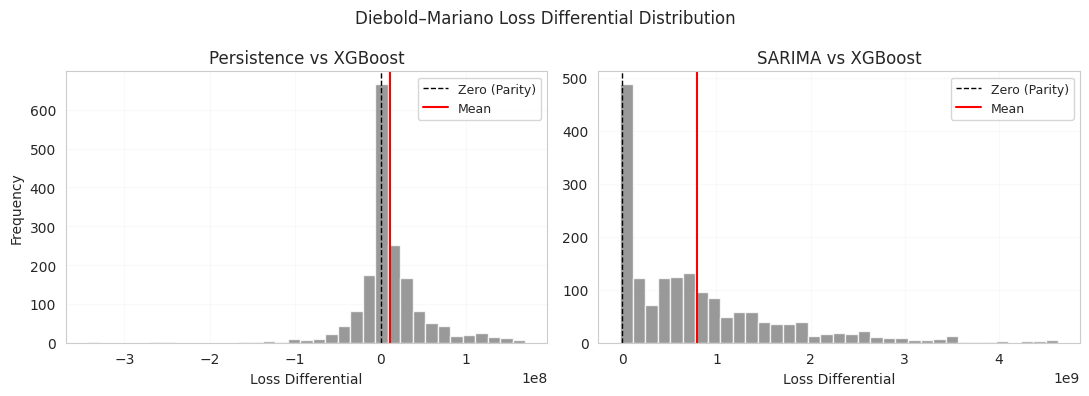

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Forecast errors for persistence and XGBoost
e_base = y_test.values - baseline_pred.values
e_xgb = y_test.values - xgb_pred

# Squared error loss differential for Persistence vs XGBoost
d_pers = (e_base**2) - (e_xgb**2)

# Squared error loss differential for SARIMA vs XGBoost (already calculated as 'd')
d_sarima = d # 'd' was calculated in cell _cXInZ_XTTMY as (e_sarima**2) - (e_xgb**2)

# ===============================
# FIGURE: DM Loss Differential
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(11,4))

# ===============================
# Persistence vs XGBoost
# ===============================
axes[0].hist(d_pers, bins=35, color='gray', alpha=0.8)

# Lines
axes[0].axvline(0, color='black', linestyle='--', linewidth=1, label="Zero (Parity)")
axes[0].axvline(np.mean(d_pers), color='red', linewidth=1.5, label="Mean")

# Labels
axes[0].set_title("Persistence vs XGBoost")
axes[0].set_xlabel("Loss Differential")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.1)

# Legend
axes[0].legend(fontsize=9)


# ===============================
# SARIMA vs XGBoost
# ===============================
axes[1].hist(d_sarima, bins=35, color='gray', alpha=0.8)

# Lines
axes[1].axvline(0, color='black', linestyle='--', linewidth=1, label="Zero (Parity)")
axes[1].axvline(np.mean(d_sarima), color='red', linewidth=1.5, label="Mean")

# Labels
axes[1].set_title("SARIMA vs XGBoost")
axes[1].set_xlabel("Loss Differential")
axes[1].grid(alpha=0.1)

# Legend
axes[1].legend(fontsize=9)


# ===============================
# Final styling
# ===============================
plt.suptitle("Diebold–Mariano Loss Differential Distribution")

plt.tight_layout()
plt.savefig("fig8_final_with_legend.png", dpi=600)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

horizons = ["1h", "6h", "24h"]
nrmse_values = [nrmse_xgb*100, nrmse_6h*100, nrmse_24h*100]

plt.figure(figsize=(6,4))

plt.plot(horizons, nrmse_values,
         marker='o',
         linewidth=2,
         color='black')

plt.xlabel("Forecast Horizon")
plt.ylabel("NRMSE (%)")
plt.title("NRMSE vs Forecast Horizon", fontsize=11)

# FIX 1: Add headroom
plt.ylim(min(nrmse_values) * 0.9, max(nrmse_values) * 1.1)

# FIX 2: Smart annotation positioning
for i, v in enumerate(nrmse_values):
    plt.text(i, v + (max(nrmse_values) * 0.02), f"{v:.2f}", ha='center', fontsize=9)

plt.grid(alpha=0.1)

plt.tight_layout()
plt.savefig("fig9_final.png", dpi=600)
plt.show()

In [60]:
test_eval["error_xgb"] = test_eval["target_1h"] - test_eval["xgb_pred"]

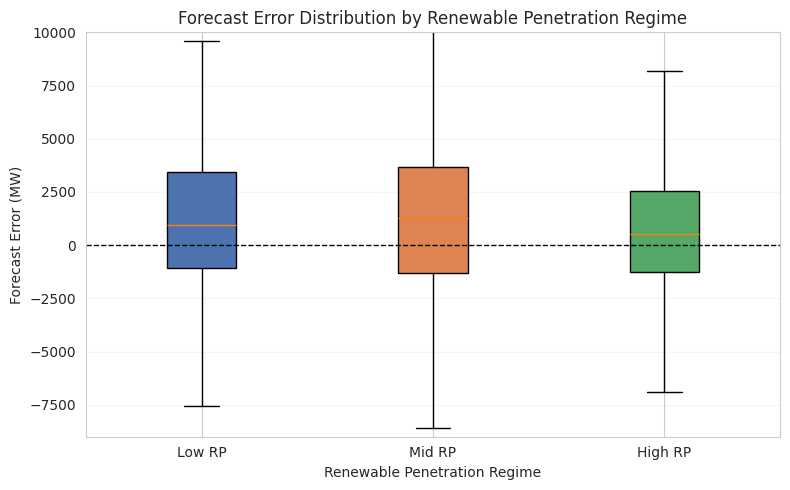

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

low = test_eval[test_eval["RP_regime_q"]=="Low"]["error_xgb"]
mid = test_eval[test_eval["RP_regime_q"]=="Mid"]["error_xgb"]
high = test_eval[test_eval["RP_regime_q"]=="High"]["error_xgb"]

bp = plt.boxplot(
[low, mid, high],
tick_labels=["Low RP", "Mid RP", "High RP"],
patch_artist=True,
showfliers=False
)

# Colors
colors = ["#4C72B0", "#DD8452", "#55A868"]
for i in range(len(bp["boxes"])):
  bp["boxes"][i].set_facecolor(colors[i])

# Zero reference line
plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.ylim(-9000, 10000)

# Labels
plt.title("Forecast Error Distribution by Renewable Penetration Regime")
plt.ylabel("Forecast Error (MW)")
plt.xlabel("Renewable Penetration Regime")

plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig("fig10_boxplot.png", dpi=600)

plt.show()